# Задание 2
- Выбрать 5 функций из учебника. Ваши функции не должны повторяться внутри подгруппы.
- Для каждой пары функций из набора построить график, содержащий две функции и их взаимнокорреляционную функцию.

1. $y = x^2$
2. $y = cos(x)$
3. $y = \frac{1}{x^2 + 2}$
4. $y = x^2 + x + 2$
5. $y = \frac{1}{(x-2)^2}$

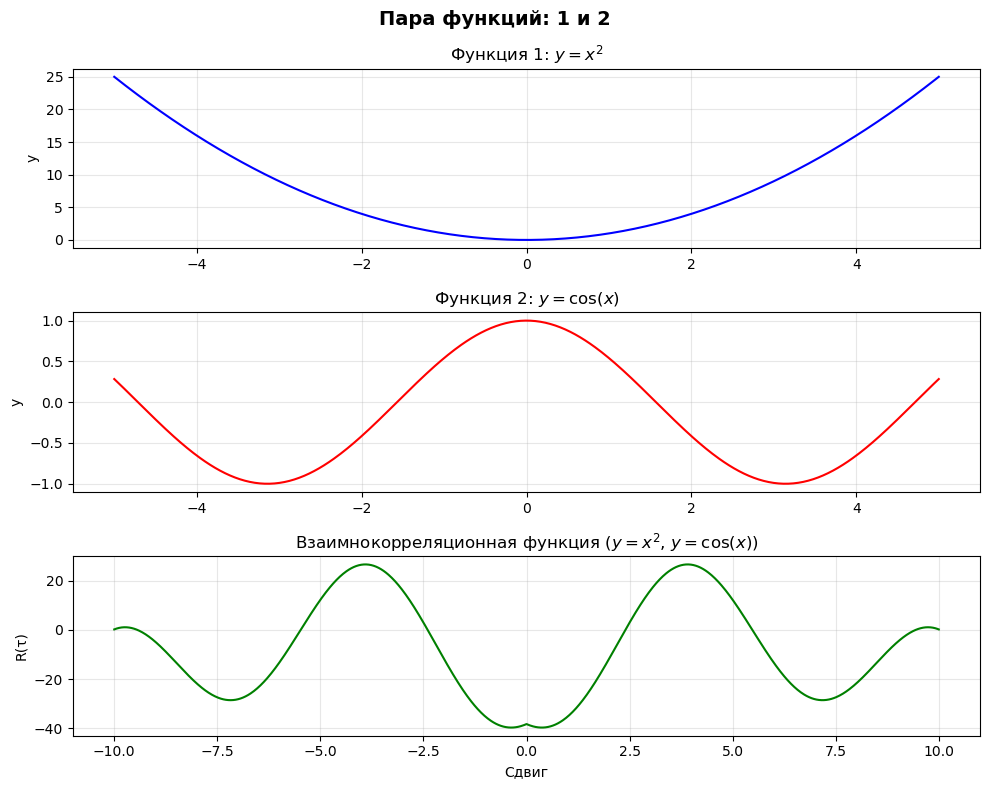

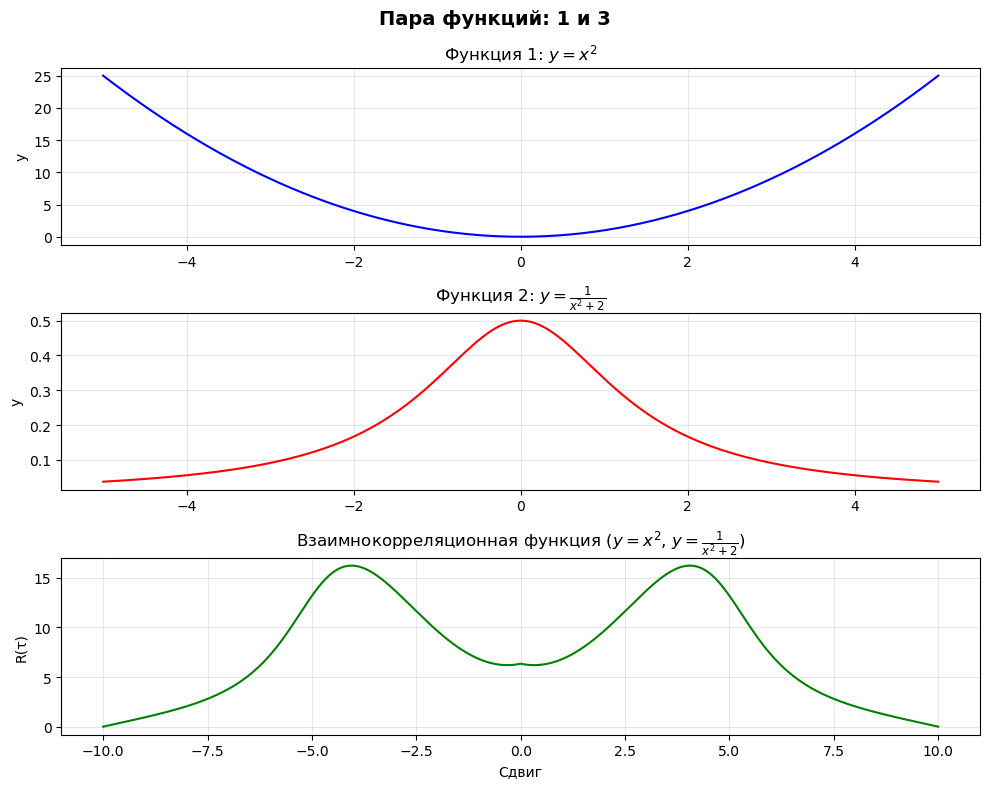

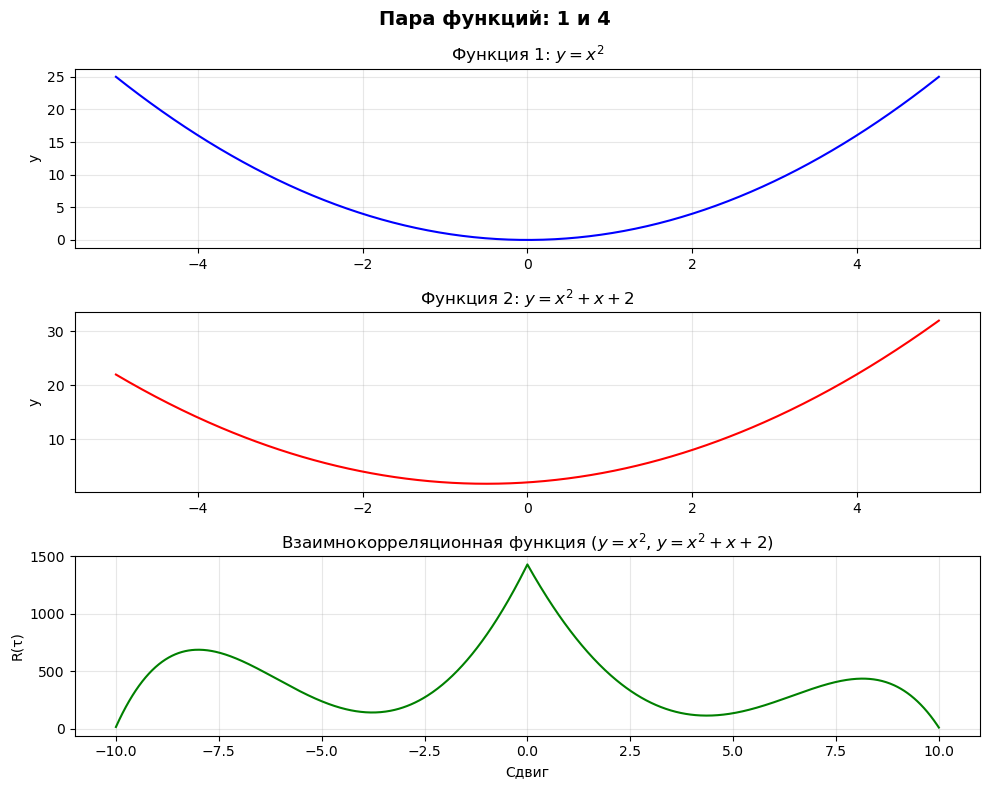

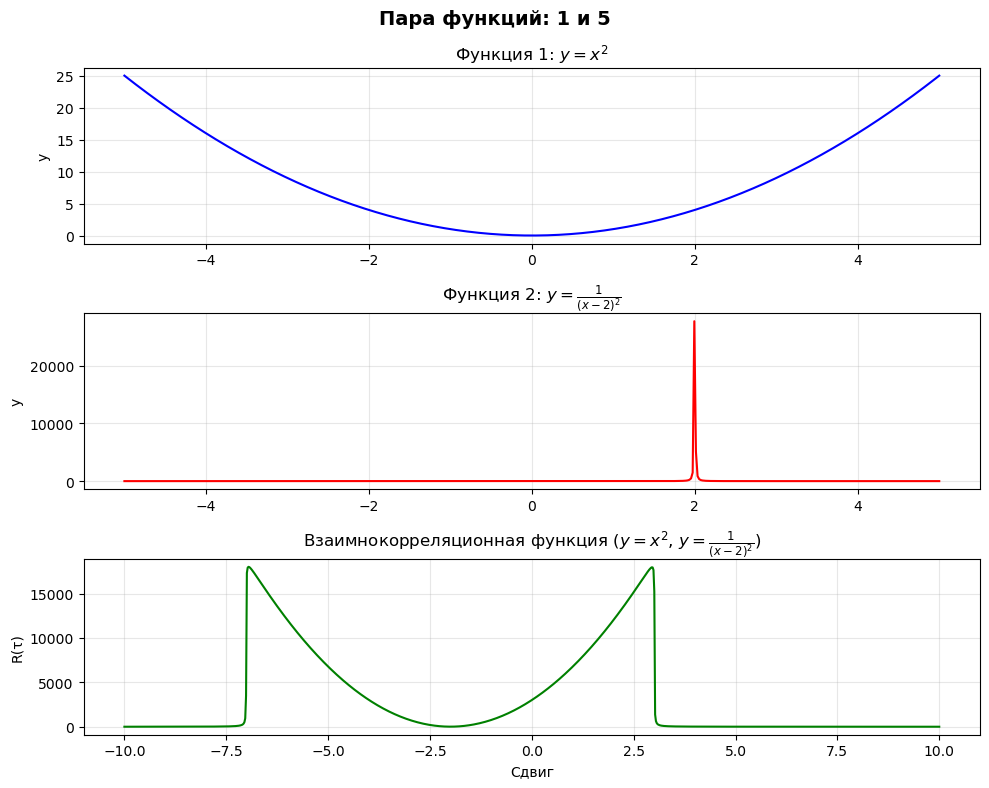

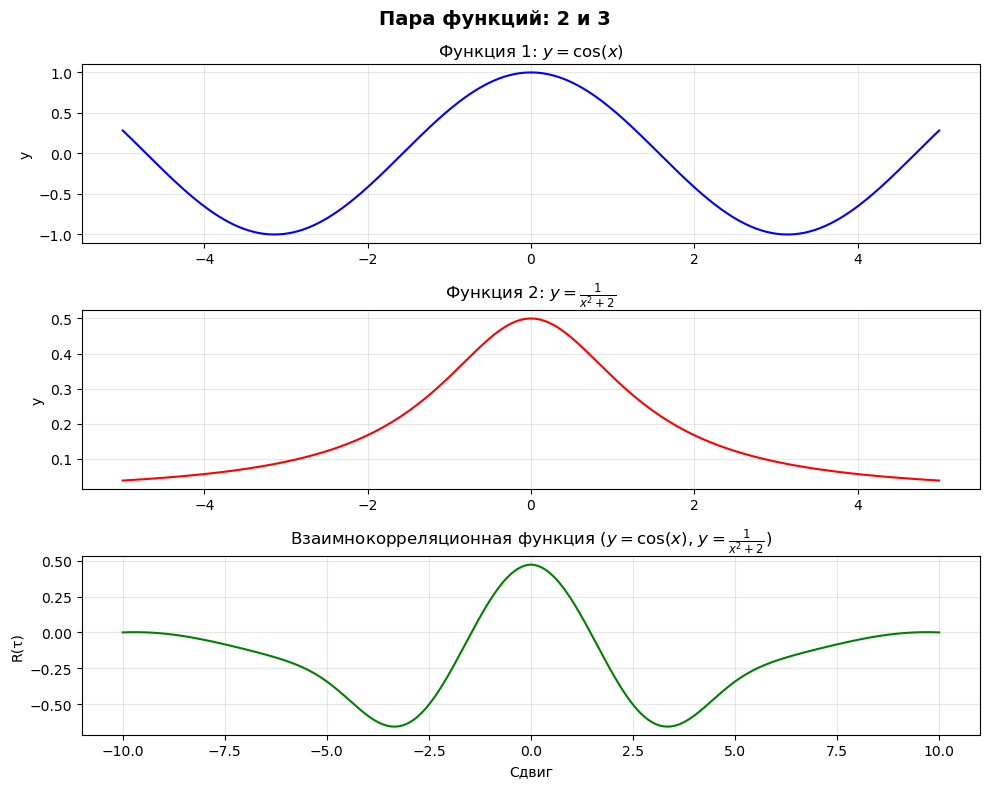

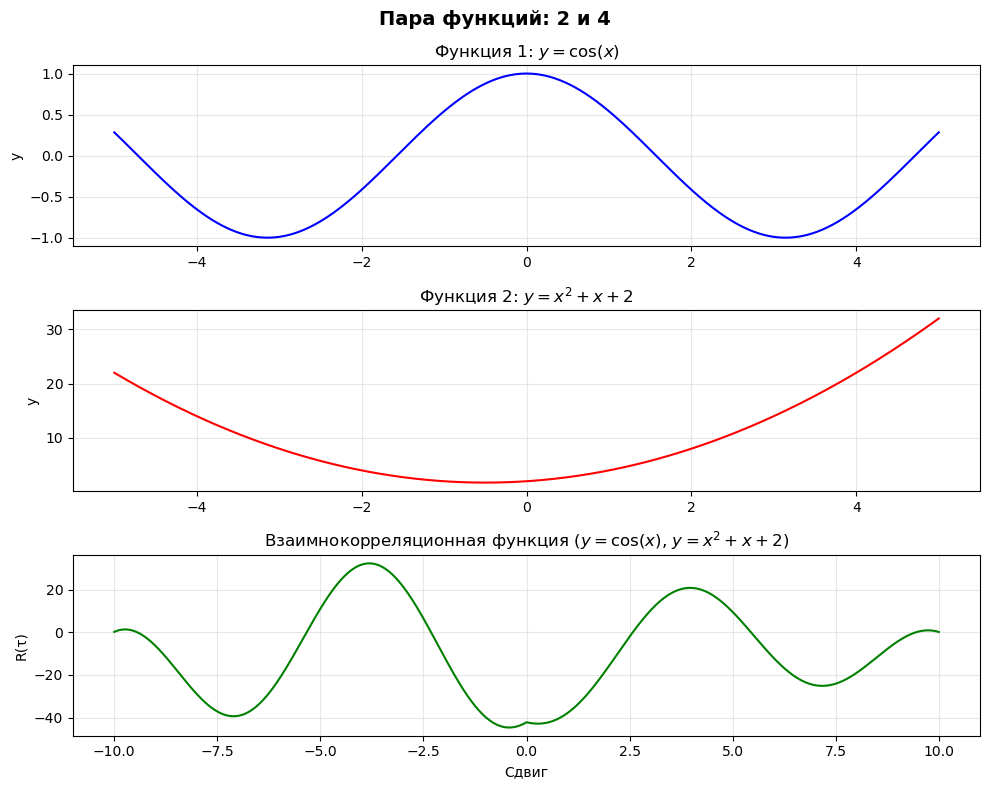

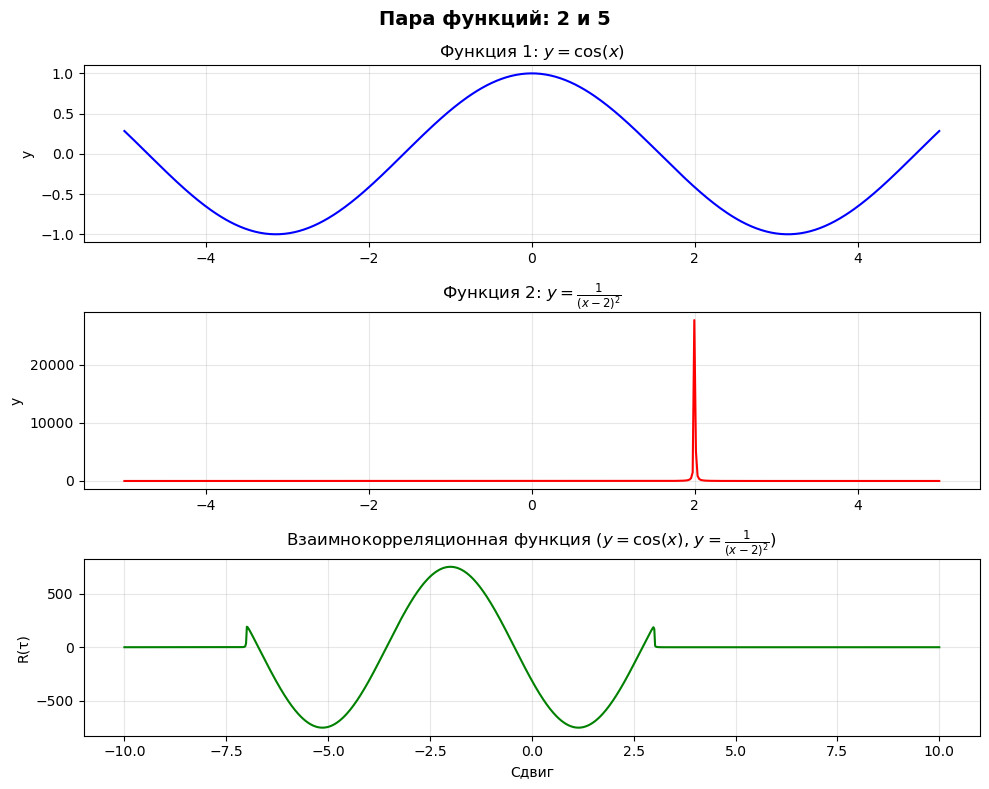

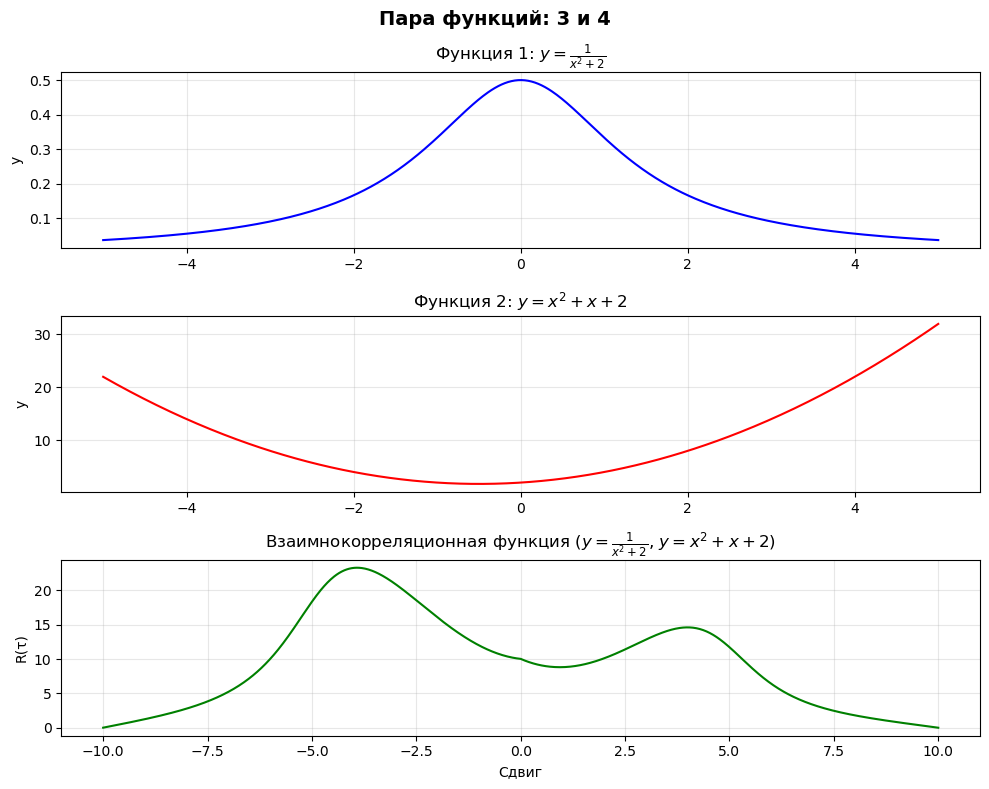

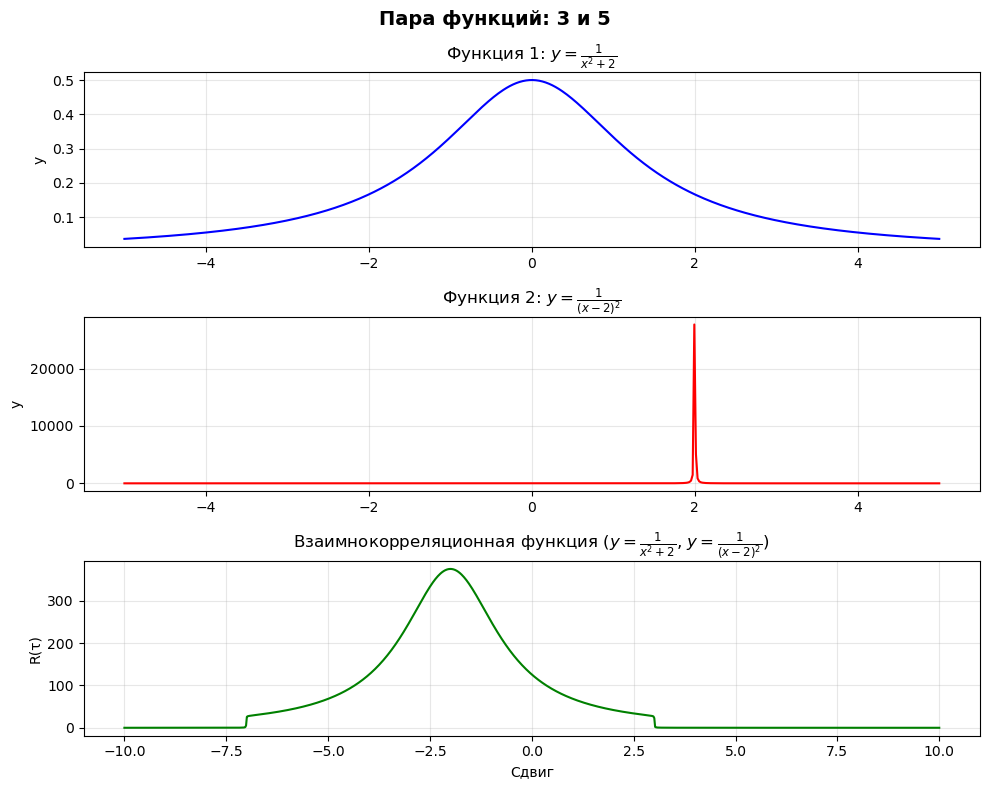

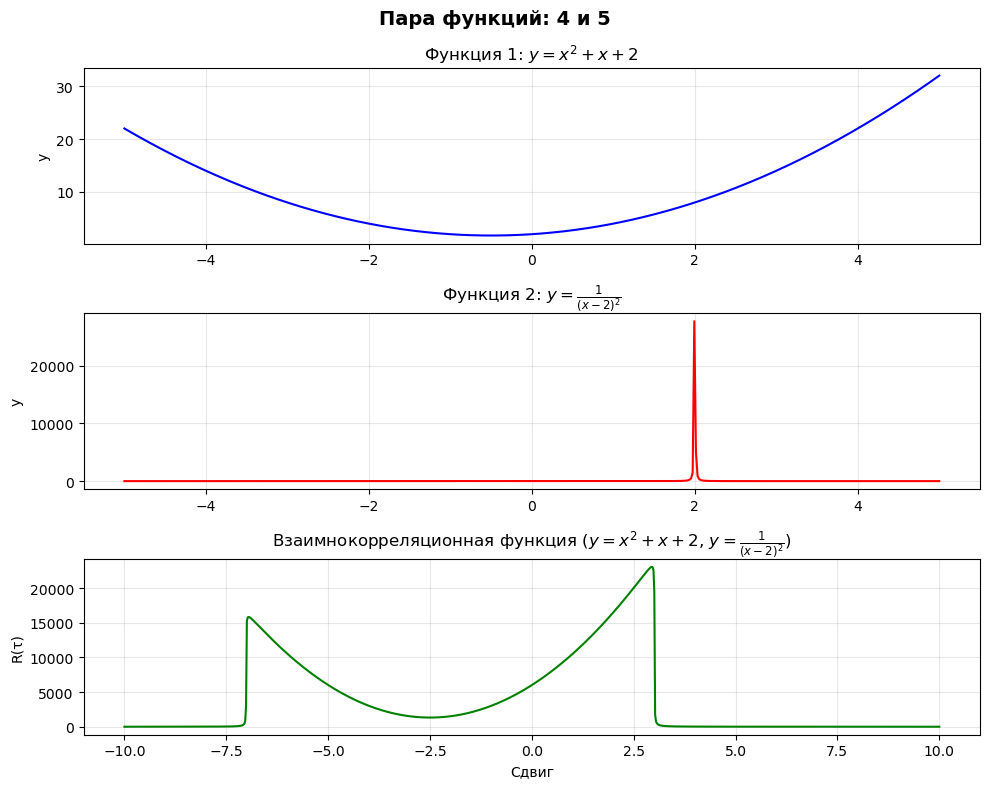

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

def f1(x):
    return x**2

def f2(x):
    return np.cos(x)

def f3(x):
    return 1 / (x**2 + 2)

def f4(x):
    return x**2 + x + 2

def f5(x):
    return 1 / ((x - 2)**2 + 1e-10)

functions = [
    (f1, r'$y = x^2$'),
    (f2, r'$y = \cos(x)$'),
    (f3, r'$y = \frac{1}{x^2 + 2}$'),
    (f4, r'$y = x^2 + x + 2$'),
    (f5, r'$y = \frac{1}{(x-2)^2}$')
]

x = np.linspace(-5, 5, 500)
dx = x[1] - x[0]

pairs = list(combinations(range(len(functions)), 2))

for (i, j) in pairs:
    fi, label_i = functions[i]
    fj, label_j = functions[j]
    
    yi = fi(x)
    yj = fj(x)
    
    yi = np.nan_to_num(yi, nan=0.0, posinf=1e10, neginf=-1e10)
    yj = np.nan_to_num(yj, nan=0.0, posinf=1e10, neginf=-1e10)
    
    corr = np.correlate(yi, yj, mode='full') * dx
    x_corr = np.linspace(2*x[0], 2*x[-1], len(corr))
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 8))
    
    axes[0].plot(x, yi, 'b-', linewidth=1.5)
    axes[0].set_title(f'Функция 1: {label_i}')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylabel('y')
    
    axes[1].plot(x, yj, 'r-', linewidth=1.5)
    axes[1].set_title(f'Функция 2: {label_j}')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylabel('y')
    
    axes[2].plot(x_corr, corr, 'g-', linewidth=1.5)
    axes[2].set_title(f'Взаимнокорреляционная функция ({label_i}, {label_j})')
    axes[2].grid(True, alpha=0.3)
    axes[2].set_xlabel('Сдвиг')
    axes[2].set_ylabel('R(τ)')
    
    plt.suptitle(f'Пара функций: {i+1} и {j+1}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()